In [21]:
# =============================================================
# HOW TO USE THIS WITH REAL DESK DATA
# =============================================================
# 1. Replace the fake DataFrames with real file imports:
#
#    positions = pd.read_csv("../data/positions.csv")
#    prices    = pd.read_csv("../data/prices.csv")
#    OR
#    positions = pd.read_excel("../data/positions.xlsx", sheet_name="Positions")
#    prices    = pd.read_excel("../data/prices.xlsx",    sheet_name="Prices")
#
# 2. Drop your real files into the /data folder
#
# 3. Check column names match — if the real file uses different column names, rename them to match this notebook:
#
#    positions = positions.rename(columns={
#        "Trader Name": "trader",
#        "CUSIP":       "cusip",
#        "Desk":        "desk",
#        "Shares":      "shares",
#        "Cost Price":  "cost"
#    })
#
# 4. Everything else in the notebook runs unchanged
# =============================================================

  trader   cusip        desk  shares    cost
0   Alex  XS1001  corp_loans    1000   98.50
1  James  XS1002  corp_loans     500  101.25
2  Sarah  XS1003  non_agency    2000   95.00
3   Alex  XS1004  non_agency    1500  102.00
4  James  XS1005  corp_loans     800   99.75
5  Sarah  XS1006  non_agency     600   96.50
    cusip   price
0  XS1001   99.75
1  XS1002  100.50
2  XS1003   96.25
3  XS1004  101.00
4  XS1005  100.80
5  XS1006   97.50
  trader   cusip        desk  shares    cost   price     pnl
0   Alex  XS1001  corp_loans    1000   98.50   99.75  1250.0
1  James  XS1002  corp_loans     500  101.25  100.50  -375.0
2  Sarah  XS1003  non_agency    2000   95.00   96.25  2500.0
3   Alex  XS1004  non_agency    1500  102.00  101.00 -1500.0
4  James  XS1005  corp_loans     800   99.75  100.80   840.0
5  Sarah  XS1006  non_agency     600   96.50   97.50   600.0


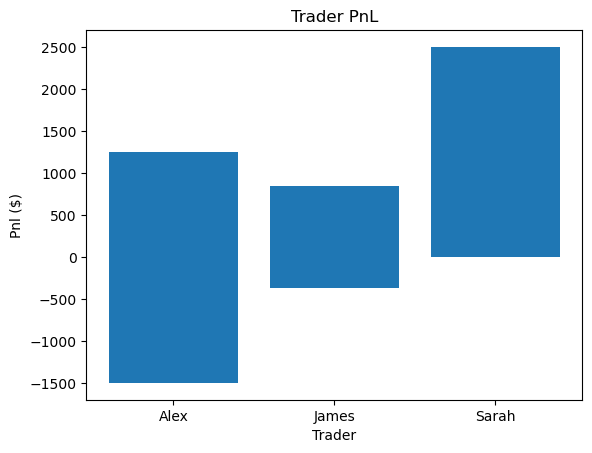

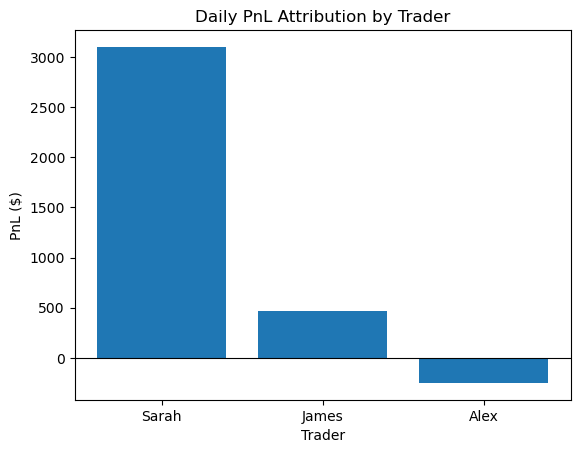

trader
Sarah    3100.0
James     465.0
Alex     -250.0
Name: pnl, dtype: float64


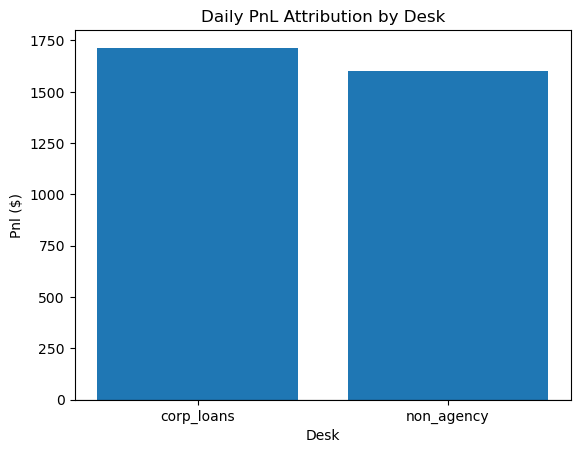

desk
corp_loans    1715.0
non_agency    1600.0
Name: pnl, dtype: float64
exported


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# fake position file — 6 trades across 3 desks
positions = pd.DataFrame({
    "trader":   ["Alex", "James", "Sarah", "Alex", "James", "Sarah"],
    "cusip":    ["XS1001", "XS1002", "XS1003", "XS1004", "XS1005", "XS1006"],
    "desk":     ["corp_loans", "corp_loans", "non_agency", "non_agency", "corp_loans", "non_agency"],
    "shares":   [1000, 500, 2000, 1500, 800, 600],
    "cost":     [98.50, 101.25, 95.00, 102.00, 99.75, 96.50]
})

# today's prices
prices = pd.DataFrame({
    "cusip": ["XS1001", "XS1002", "XS1003", "XS1004", "XS1005", "XS1006"],
    "price": [99.75, 100.50, 96.25, 101.00, 100.80, 97.50]
})

print(positions)
print(prices)

df = pd.merge(positions, prices, on="cusip", how="left")
df["pnl"] = (df["price"] - df["cost"]) * df["shares"]
print(df)

# Plot
plt.bar(df["trader"],df["pnl"])
plt.xlabel("Trader")
plt.ylabel("Pnl ($)")
plt.title("Trader PnL")
plt.show()

# PnL by trader
pnl_by_trader = df.groupby("trader")["pnl"].sum().sort_values(ascending=False)

# Plot of PnL by Trader
plt.bar(pnl_by_trader.index, pnl_by_trader.values)
plt.xlabel("Trader")
plt.ylabel("PnL ($)")
plt.title("Daily PnL Attribution by Trader")
plt.axhline(y=0, color="black", linewidth=0.8)  # zero line
plt.show()

# Table of PnL by Trader
print(pnl_by_trader)

# PnL by Desk
pnl_by_desk=df.groupby("desk")["pnl"].sum().sort_values(ascending=False)

# Plot of PnL by Desk
plt.bar(pnl_by_desk.index,pnl_by_desk.values)
plt.xlabel("Desk")
plt.ylabel("Pnl ($)")
plt.title("Daily PnL Attribution by Desk")
plt.axhline(y=0,color="black",linewidth=0.8)
plt.show()

# Table of PnL by Desk
print(pnl_by_desk)

# Summary Table
summary = df[["trader", "desk", "cusip", "shares", "cost", "price", "pnl"]]

# Export to Excel
summary.to_excel("pnl_attribution.xlsx", index=False, sheet_name="Daily PnL")

print("exported")

SyntaxError: invalid syntax (1506009758.py, line 1)